<a href="https://colab.research.google.com/github/ayesha942/MentalHealthAnalysis/blob/main/MentalHealthAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/sample_data/scores.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

df.replace("NA", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)
df.replace(" ", np.nan, inplace=True)

df["group"] = df["number"].apply(
    lambda x: "Patient" if "condition" in str(x).lower() else "Control"
)
# ==============================
def age_midpoint(age_range):
    if pd.isna(age_range):
        return np.nan

    try:
        low, high = age_range.split("-")
        return (int(low) + int(high)) / 2
    except:
        return np.nan

df["age_numeric"] = df["age"].apply(age_midpoint)

numeric_cols = [
    "days",
    "gender",
    "afftype",
    "melanch",
    "inpatient",
    "marriage",
    "work",
    "madrs1",
    "madrs2"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nGender Values:")
print(df["gender"].value_counts(dropna=False))


df["gender"] = df["gender"].replace({
    1: "Male",
    2: "Female"
})

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)


print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


df["improvement"] = df["madrs1"] - df["madrs2"]

def severity(score):
    if pd.isna(score):
        return np.nan
    elif score <= 10:
        return "Mild"
    elif score <= 20:
        return "Moderate"
    else:
        return "Severe"

df["severity"] = df["madrs1"].apply(severity)

print("\nFinal Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Cleaned Rows:")
print(df.head())

df.to_csv("mental_health_cleaned.csv", index=False)

print("\nCleaned dataset saved as 'mental_health_cleaned.csv'")


Dataset Shape: (55, 12)

First 5 Rows:
        number  days  gender    age  afftype  melanch  inpatient    edu  \
0  condition_1    11       2  35-39      2.0      2.0        2.0   6-10   
1  condition_2    18       2  40-44      1.0      2.0        2.0   6-10   
2  condition_3    13       1  45-49      2.0      2.0        2.0   6-10   
3  condition_4    13       2  25-29      2.0      2.0        2.0  11-15   
4  condition_5    13       2  50-54      2.0      2.0        2.0  11-15   

   marriage  work  madrs1  madrs2  
0       1.0   2.0    19.0    19.0  
1       2.0   2.0    24.0    11.0  
2       2.0   2.0    24.0    25.0  
3       1.0   1.0    20.0    16.0  
4       2.0   2.0    26.0    26.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   number     55 non-null     object 
 1   days       55 non-null     int64  
 2   gender     

In [ ]:
print(df.shape)

print(df["group"].value_counts())

print(df["gender"].value_counts())

print(df["age"].value_counts())
# Questions:
# How many patients vs controls?
# Male vs female distribution?
# Most common age group?

(55, 16)
group
Control    32
Patient    23
Name: count, dtype: int64
gender
Male      30
Female    25
Name: count, dtype: int64
age
50-54    9
45-49    9
25-29    7
35-39    7
30-34    7
20-24    6
40-44    5
60-64    2
65-69    2
55-59    1
Name: count, dtype: int64


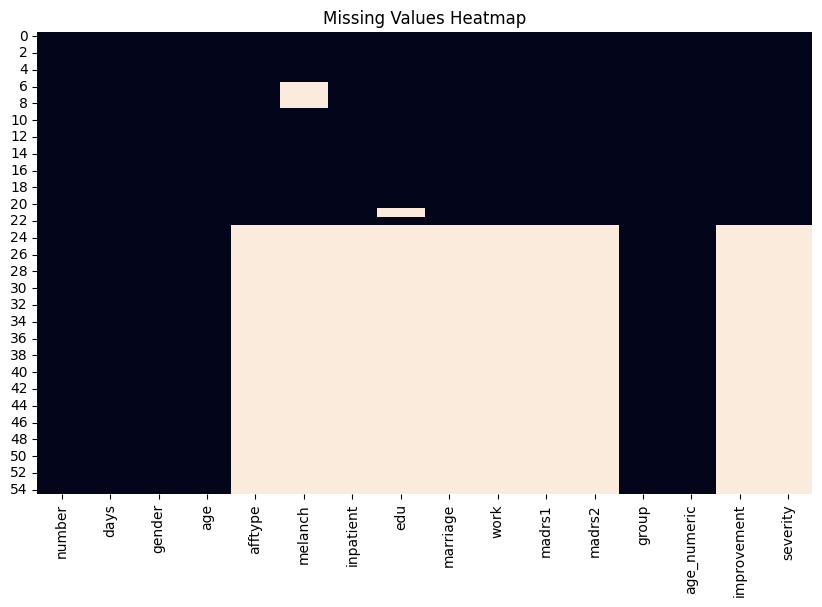

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

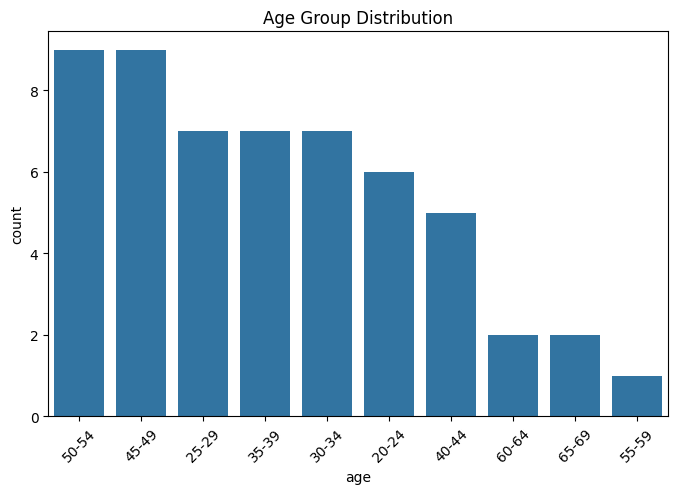

In [ ]:

# Which age groups dominate the dataset?
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="age",
    order=df["age"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Age Group Distribution")
plt.show()

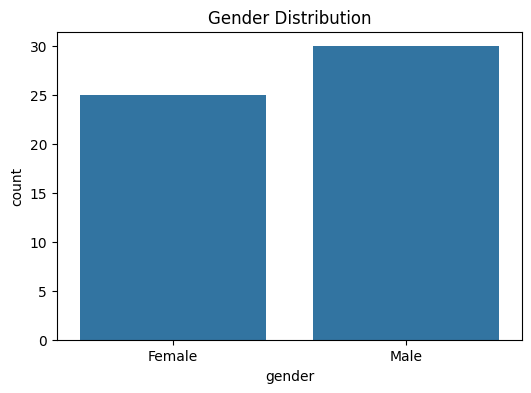

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")
plt.show()

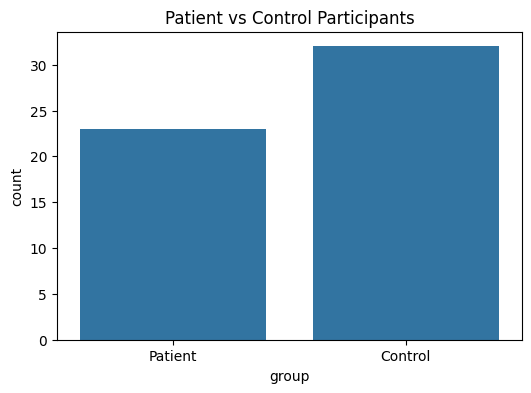

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="group"
)
plt.title("Patient vs Control Participants")
plt.show()

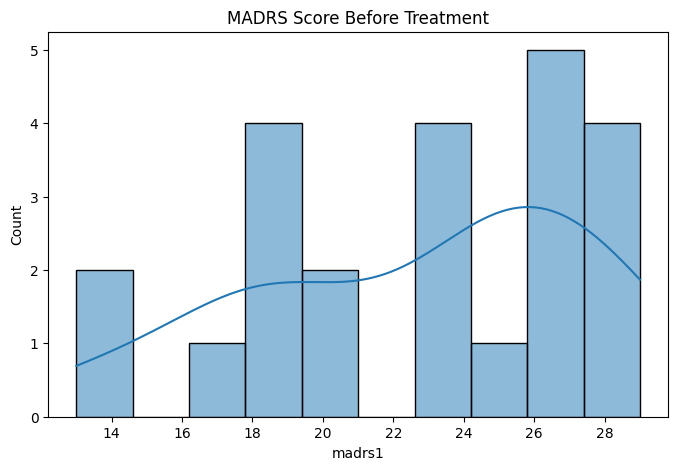

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["madrs1"],
    bins=10,
    kde=True
)

plt.title("MADRS Score Before Treatment")
plt.show()

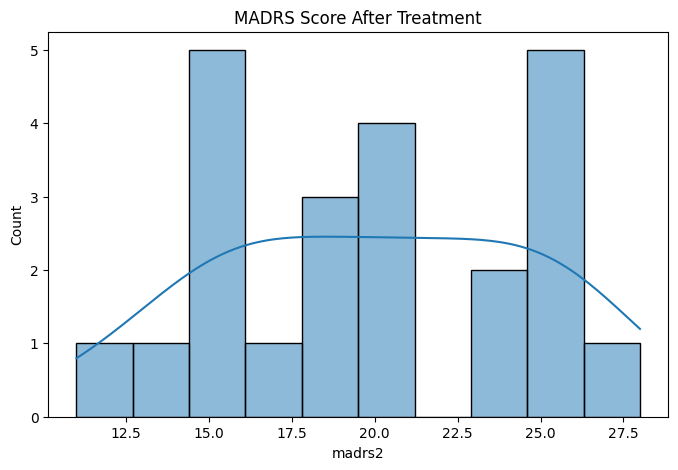

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["madrs2"],
    bins=10,
    kde=True
)

plt.title("MADRS Score After Treatment")
plt.show()

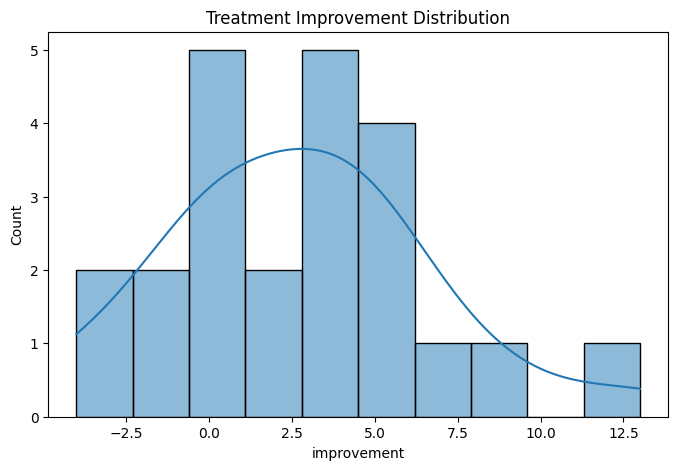

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["improvement"],
    bins=10,
    kde=True
)

plt.title("Treatment Improvement Distribution")
plt.show()



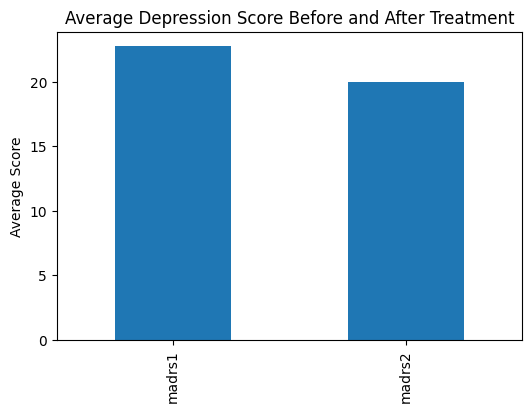

In [ ]:
scores = df[["madrs1", "madrs2"]].mean()

plt.figure(figsize=(6,4))

scores.plot(kind="bar")

plt.title("Average Depression Score Before and After Treatment")
plt.ylabel("Average Score")

plt.show()

In [ ]:
print("Average MADRS Before:",
      df["madrs1"].mean())

print("Average MADRS After:",
      df["madrs2"].mean())

print("Average Improvement:",
      df["improvement"].mean())

Average MADRS Before: 22.73913043478261
Average MADRS After: 20.0
Average Improvement: 2.739130434782609
